<a href="https://colab.research.google.com/github/silasfljr/STD_geoprog/blob/main/PCA_Crop_Recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://raw.githubusercontent.com/silasfljr/STD_geoprog/refs/heads/main/IA_AGRO/Crop_recommendation.csv

--2026-04-02 13:37:36--  https://raw.githubusercontent.com/silasfljr/STD_geoprog/refs/heads/main/IA_AGRO/Crop_recommendation.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150034 (147K) [text/plain]
Saving to: ‘Crop_recommendation.csv’

Crop_recommendation 100%[===================>] 146.52K  --.-KB/s    in 0.02s   

2026-04-02 13:37:36 (6.54 MB/s) - ‘Crop_recommendation.csv’ saved [150034/150034]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Carregar o dataset
df = pd.read_csv('Crop_recommendation.csv')
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [ ]:
# Separar features (X) e o alvo (y)
X = df.drop('label', axis=1)
y = df['label']

Como o PCA busca maximizar a variância, se uma variável estiver em uma escala muito maior (ex: Rainfall vs pH), ela dominará o componente injustamente. Usamos o StandardScaler para que todas tenham média 0 e variância 1.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Nesta etapa, calculamos todos os componentes possíveis para decidir quantos são necessários para explicar a maior parte da informação.

In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Visualizando a Variância (Gráfico de Cotovelo)

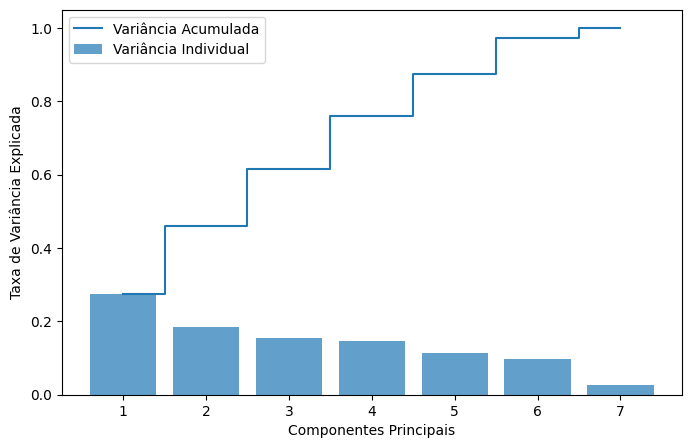

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Variância Individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Variância Acumulada')
plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.legend(loc='best')
plt.show()

Análise de Biplot (Cargas dos Componentes)

Para entender o que cada componente representa (ex: "O PC1 é influenciado por P e K?"), analisamos as cargas (loadings).

In [ ]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(X.columns))], index=X.columns)
print("Cargas dos dois primeiros componentes:")
print(loadings[['PC1', 'PC2']])

Cargas dos dois primeiros componentes:
                  PC1       PC2
N           -0.302191  0.334107
P            0.643787  0.034358
K            0.622607  0.283829
temperature -0.212428  0.359487
humidity    -0.068483  0.737917
ph          -0.226943 -0.220657
rainfall    -0.072532  0.290158


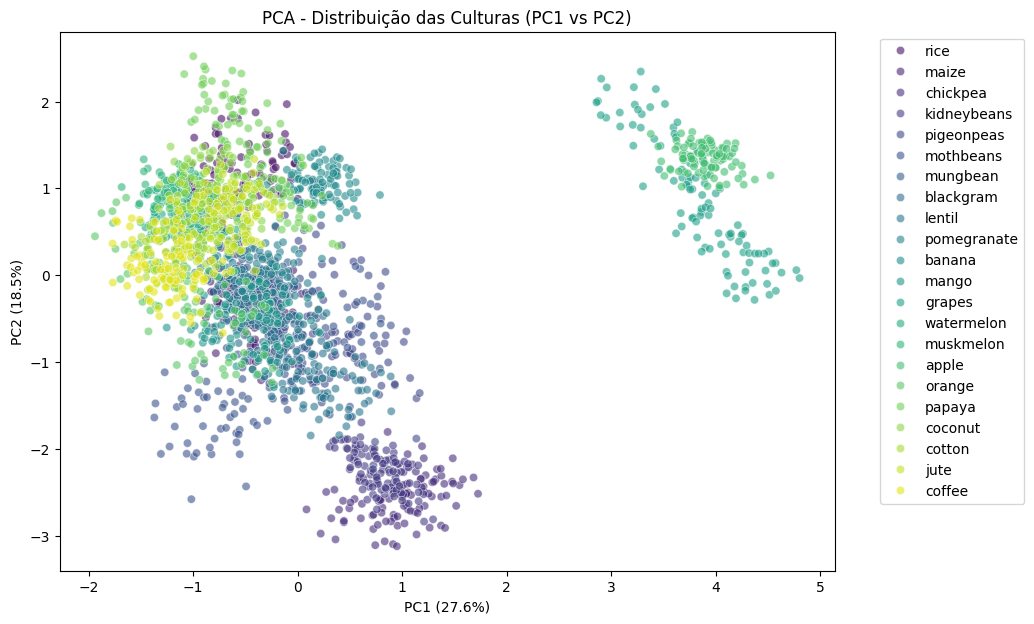

In [ ]:
# Visualização 2D dos Clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.6)
plt.title('PCA - Distribuição das Culturas (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

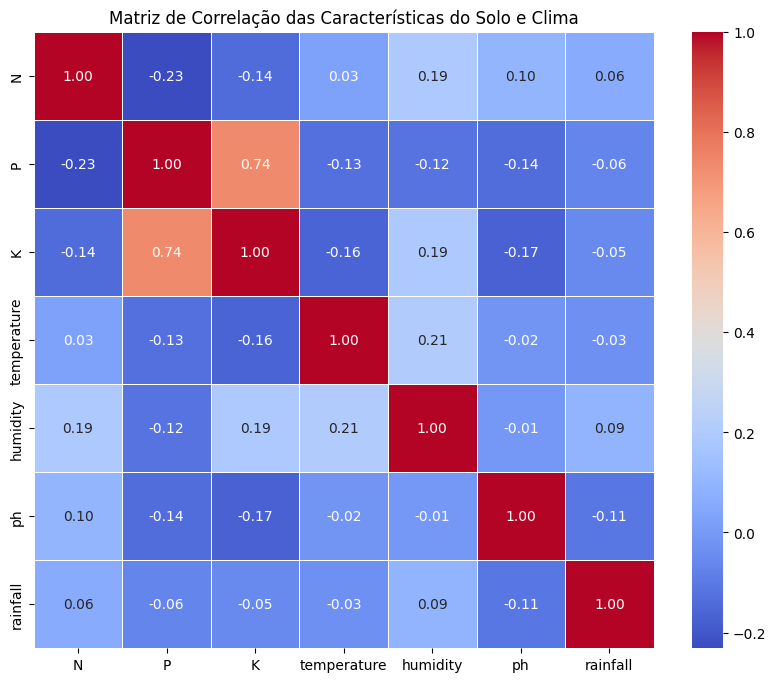

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar dados
df = pd.read_csv('Crop_recommendation.csv')
features = df.drop('label', axis=1)

# Calcular a matriz de correlação
corr_matrix = features.corr()

# Plotar o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Características do Solo e Clima')
plt.show()

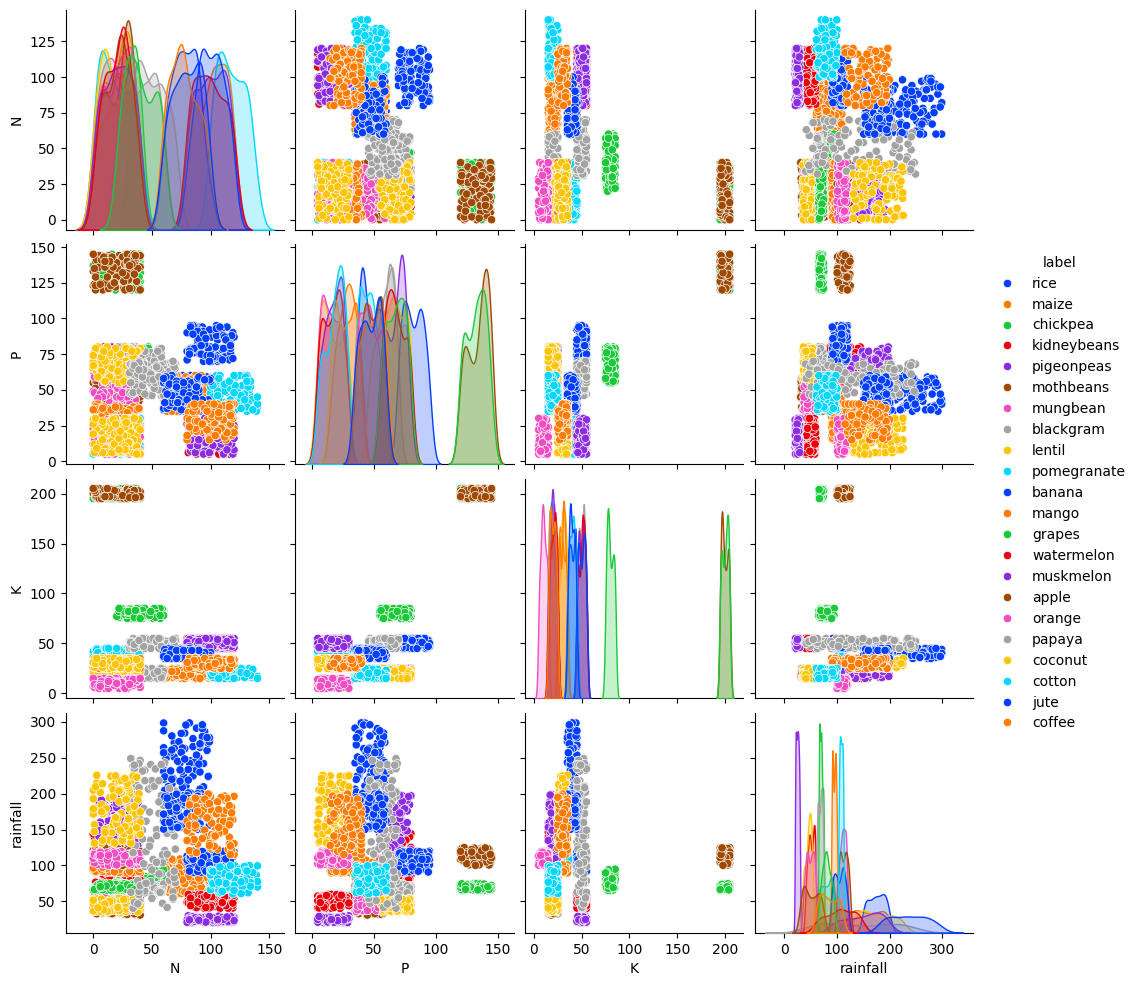

In [ ]:
# Selecionando algumas colunas chave para não pesar o gráfico
selected_cols = ['N', 'P', 'K', 'rainfall', 'label']
sns.pairplot(df[selected_cols], hue='label', palette='bright', diag_kind='kde')
plt.show()

## outro

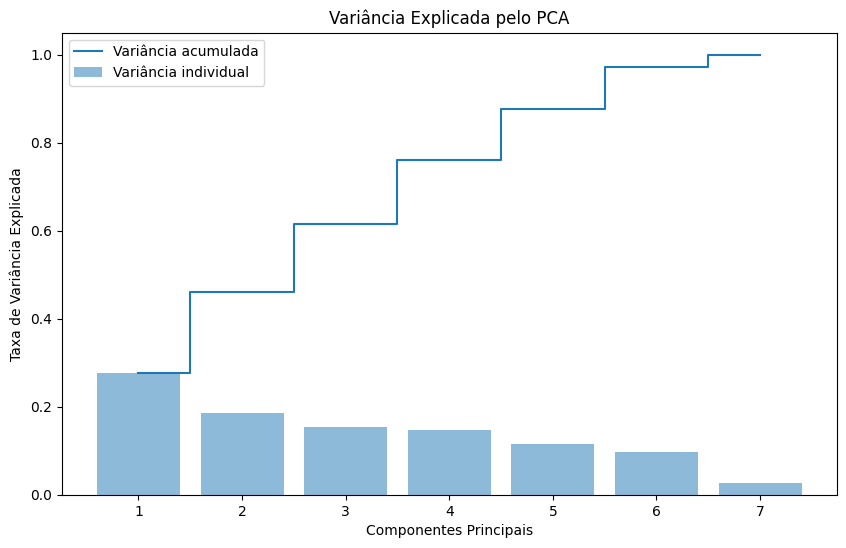

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Carregar os dados
df = pd.read_csv('Crop_recommendation.csv')
X = df.drop('label', axis=1)
y = df['label']

# 2. Padronização (Essencial para PCA)
# Como vimos na correlação, as escalas são diferentes (ex: pH vs Rainfall)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar o PCA
# Vamos manter todos os componentes inicialmente para analisar a variância
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Gráfico de Variância Explicada (Scree Plot)
exp_var_pca = pca.explained_variance_ratio_
cum_var_pca = np.cumsum(exp_var_pca)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center', label='Variância individual')
plt.step(range(1, len(cum_var_pca) + 1), cum_var_pca, where='mid', label='Variância acumulada')
plt.ylabel('Taxa de Variância Explicada')
plt.xlabel('Componentes Principais')
plt.title('Variância Explicada pelo PCA')
plt.legend(loc='best')
plt.show()

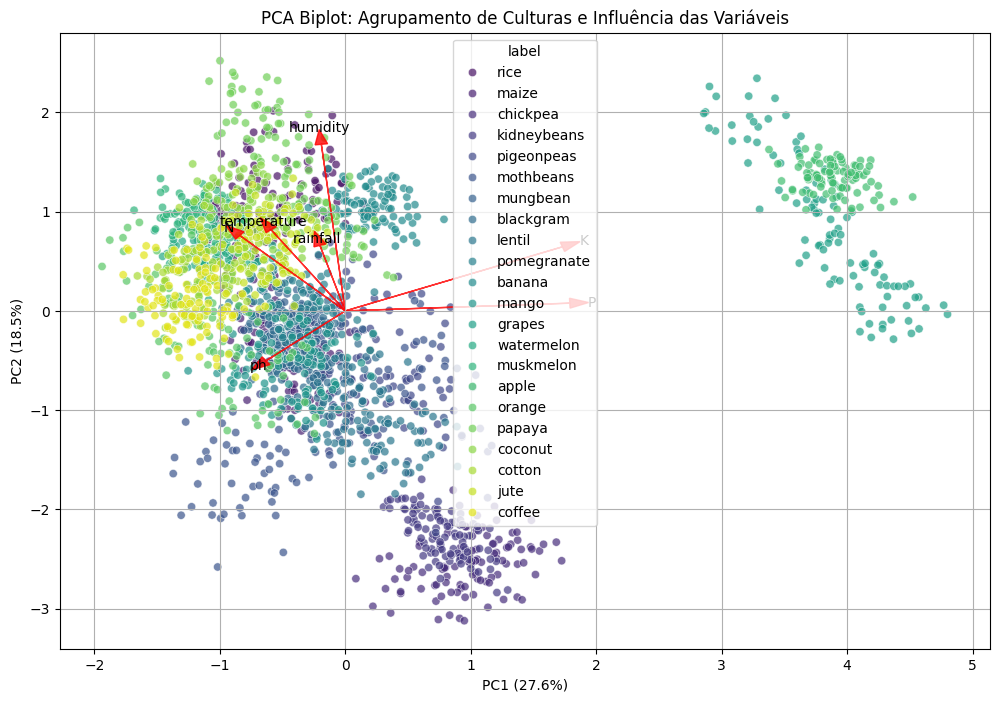

In [ ]:
# Criar um DataFrame com os resultados do PCA
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['label'] = y

# Plotar
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='label', data=pca_df, palette='viridis', alpha=0.7)

# Adicionar as "setas" das cargas (loadings) para ver a influência de cada variável
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
features = X.columns
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2, color='red', alpha=0.8, head_width=0.1)
    plt.text(loadings[i, 0]*2.2, loadings[i, 1]*2.2, feature, color='black', ha='center', va='center')

plt.title('PCA Biplot: Agrupamento de Culturas e Influência das Variáveis')
plt.xlabel(f'PC1 ({exp_var_pca[0]:.1%})')
plt.ylabel(f'PC2 ({exp_var_pca[1]:.1%})')
plt.grid(True)
plt.show()